In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# sctrial: Comprehensive Workflow Tutorial
## Trial-Aware Single-Cell Inference

This notebook provides an in-depth demonstration of the `sctrial` package capabilities. We use a synthetic dataset designed to mirror a complex clinical trial with:
- Multiple participants and visits (Longitudinal)
- Treatment and Control arms (Randomized)
- Multiple cell types (Stratified)
- Known biological signals (Validation)

---


In [2]:
import sctrial as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anndata import AnnData
from scipy import sparse

# Set seed for reproducibility
np.random.seed(42)

def generate_clustered_data(n_obs, n_vars, n_clusters=4):
    # Simulate 2D UMAP-like clusters with 4 distinct groups
    from sklearn.datasets import make_blobs
    centers = [[0, 0], [10, 10], [15, 0], [0, 15]]
    X_umap, y = make_blobs(n_samples=n_obs, centers=centers, cluster_std=1.2, random_state=42)
    
    # Map clusters to cell types
    celltypes = np.array(["TypeA", "TypeB", "TypeC", "TypeD"])[y]
    
    # Generate expression data that correlates with clusters
    X = np.random.poisson(0.1, size=(n_obs, n_vars)).astype(float)
    for i in range(n_clusters):
        mask = (y == i)
        # Cluster-specific markers (5 genes each)
        X[mask, i*10:(i*10)+5] += 3.0 
        
    return X, X_umap, celltypes


## 1. Data Generation: Building a Virtual Clinical Trial

We create a dataset with 30 participants, 2 visits (Baseline, Followup), and 2 arms (Treated, Control).
We also simulate two cell types (TypeA, TypeB) with distinct clusters and response profiles.


In [3]:
n_participants = 30
n_genes = 200
visits = ["Baseline", "Followup"]
arms = ["Treated", "Control"]

rows = []
for i in range(n_participants):
    arm = "Treated" if i < n_participants // 2 else "Control"
    for v in visits:
        # 60 cells per participant per visit
        for _ in range(60):
            rows.append({
                "participant_id": f"P{i}",
                "visit": v,
                "arm": arm,
                "age": 45 + (i % 5) * 4,
                "batch": f"Batch_{i % 3}"
            })

obs = pd.DataFrame(rows)
X, X_umap, celltypes = generate_clustered_data(len(obs), n_genes)
obs["celltype"] = celltypes

# --- Inject Signals ---

# 1. Global Treatment Effect (TypeA & TypeB) in Genes 0-4
# We'll make it very strong to ensure clear p-values and GSEA signal
treated_followup = (obs["arm"] == "Treated") & (obs["visit"] == "Followup")
X[treated_followup, :5] += 6.0

# 2. Cell-type Specific Effect (TypeB only) in Genes 5-9
typeB_treated_followup = treated_followup & (obs["celltype"] == "TypeB")
X[typeB_treated_followup, 5:10] += 10.0

# 3. Add more interesting signals for GSEA (TypeC and TypeD)
typeC_treated_followup = treated_followup & (obs["celltype"] == "TypeC")
X[typeC_treated_followup, 20:25] += 8.0

typeD_treated_followup = treated_followup & (obs["celltype"] == "TypeD")
X[typeD_treated_followup, 30:35] += 7.0

# 3. Abundance Shift: Increase in TypeA in Treated Followup
# We'll adjust the 'celltype' labels for a subset of cells to simulate a composition shift
mask_shift = (obs["arm"] == "Treated") & (obs["visit"] == "Followup") & (obs["celltype"] == "TypeB")
indices_to_shift = obs[mask_shift].sample(frac=0.4, random_state=42).index
obs.loc[indices_to_shift, "celltype"] = "TypeA"

adata = AnnData(X=sparse.csr_matrix(X), obs=obs)
adata.obsm["X_umap"] = X_umap
adata.var_names = [f"Gene{i}" for i in range(n_genes)]
adata.layers["counts"] = adata.X.copy()

print(f"Created AnnData with {adata.n_obs} cells and {adata.n_vars} genes.")
print(f"Arms: {adata.obs['arm'].unique()}")
print(f"Visits: {adata.obs['visit'].unique()}")
print(f"Cell types: {adata.obs['celltype'].unique()}")


Created AnnData with 3600 cells and 200 genes.
Arms: ['Treated' 'Control']
Visits: ['Baseline' 'Followup']
Cell types: ['TypeA' 'TypeB' 'TypeC' 'TypeD']


## 2. Defining the Trial Design

The `TrialDesign` object centralizes your study metadata.


In [4]:
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="visit",
    arm_col="arm",
    arm_treated="Treated",
    arm_control="Control",
    celltype_col="celltype",
    baseline_visit="Baseline",
    followup_visit="Followup"
)

# Validate consistency
design.validate(adata)
print("Trial design validated successfully.")


Trial design validated successfully.


## 3. Preprocessing & Module Scoring

We normalize the data and aggregate gene signals into functional "Module Scores".


In [5]:
# Normalization: log1p(CPM)
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

# Define biological pathways
gene_sets = {
    "Inflammatory_Response": ["Gene0", "Gene1", "Gene2"],
    "TypeB_Activation": ["Gene5", "Gene6", "Gene7"],
    "Metabolic_Control": ["Gene20", "Gene21", "Gene22"]
}

# Compute module scores using the 'zmean' method (z-score genes across cells then mean)
adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="zmean", prefix="ms_")

# Preview the new scores in metadata
print("Added module scores:", [c for c in adata.obs.columns if c.startswith("ms_")])


Added module scores: ['ms_Inflammatory_Response', 'ms_TypeB_Activation', 'ms_Metabolic_Control']


## 4. Difference-in-Differences (DiD) Analysis
### Testing the Primary Treatment Effect

We test the "divergence" between arms from Baseline to Followup.


In [6]:
# Global DiD (Aggregated to participant-visit level)
did_res = st.did_table(
    adata, 
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation", "ms_Metabolic_Control"],
    design=design,
    visits=("Baseline", "Followup"),
    aggregate="participant_visit",
    covariates=["age"] # Control for age
)

print("--- Global DiD Results ---")
print(st.summarize_did_results(did_res))
display(did_res)


--- Global DiD Results ---
## Trial-Aware DiD Summary
Total features tested: 3
Significant (p < 0.05): 2
Significant (FDR < 0.05): 2

### Top Upregulated Features (by p-value):
- ms_Inflammatory_Response: beta=2.194, p=7.37e-89
- ms_TypeB_Activation: beta=2.211, p=7.39e-27
- ms_Metabolic_Control: beta=0.060, p=9.44e-01

### Top Downregulated Features (by p-value):
- None


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,2.193640,0.109762,7.373597e-89,0.001254,0.988676,30,ms_Inflammatory_Response,2.212079e-88
1,2.211331,0.206097,7.394546e-27,0.005024,0.960072,30,ms_TypeB_Activation,1.109182e-26
2,0.059613,0.844913,9.437517e-01,0.228786,0.692017,30,ms_Metabolic_Control,9.437517e-01


### Robust Inference: Wild Cluster Bootstrap
For small sample sizes or non-normal distributions, we use bootstrapping.


In [7]:
print("Running DiD with Wild Cluster Bootstrap (Rademacher)...")
did_boot = st.did_table(
    adata, 
    features=["ms_TypeB_Activation"],
    design=design,
    visits=("Baseline", "Followup"),
    use_bootstrap=True,
    n_boot=199 # Using small B for demo speed
)
print(did_boot[["feature", "beta_DiD", "p_DiD"]])


Running DiD with Wild Cluster Bootstrap (Rademacher)...


               feature  beta_DiD  p_DiD
0  ms_TypeB_Activation  2.211331    0.0


## 5. Stratified Analysis
### Treatment Effects by Cell Type

Biological responses are often cell-type specific. `did_table_by_celltype` automates this stratification.


In [8]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation"],
    design=design,
    visits=("Baseline", "Followup")
)

print("--- Stratified DiD Results ---")
display(strat_res.sort_values(["celltype", "p_DiD"]))


--- Stratified DiD Results ---


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD,celltype,FDR_DiD_stratified
0,2.136460,0.332688,1.346678e-10,0.017933,0.928988,30,ms_TypeB_Activation,2.693355e-10,TypeA,2.154684e-10
1,1.857935,0.318681,5.539986e-09,0.127482,0.422528,30,ms_Inflammatory_Response,5.539986e-09,TypeA,7.386648e-09
2,2.240588,0.061989,4.515681e-286,0.051950,0.324460,30,ms_TypeB_Activation,9.031362e-286,TypeB,3.612545e-285
3,2.263175,0.080074,9.707890e-176,0.007829,0.912217,30,ms_Inflammatory_Response,9.707890e-176,TypeB,2.588771e-175
4,2.239978,0.073411,1.760643e-204,0.007608,0.896277,30,ms_Inflammatory_Response,3.521286e-204,TypeC,7.042572e-204
5,-0.575928,0.810041,4.770927e-01,0.041367,0.931491,30,ms_TypeB_Activation,4.770927e-01,TypeC,5.452488e-01
6,2.285121,0.081235,4.223448e-174,-0.011762,0.868449,30,ms_Inflammatory_Response,8.446896e-174,TypeD,8.446896e-174
7,-0.318366,0.695721,6.472358e-01,-0.221593,0.631438,30,ms_TypeB_Activation,6.472358e-01,TypeD,6.472358e-01


## 6. Cell-Type Abundance Analysis
### Compositional Shifts

We test if the proportion of specific cell types changes in response to treatment.


In [9]:
ab_res = st.abundance_did(
    adata, 
    design=design, 
    visits=("Baseline", "Followup"),
    transform="arcsin_sqrt"
)

print("--- Abundance DiD Results ---")
display(ab_res)


--- Abundance DiD Results ---


,celltype,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD
0,TypeB,30,-0.117836,0.033426,0.001476,-0.017852,0.456384,0.005904
1,TypeA,30,0.070467,0.034385,0.049899,0.003869,0.874698,0.099798
2,TypeD,30,0.015335,0.036440,0.677085,0.003974,0.878545,0.720661
3,TypeC,30,0.011377,0.031497,0.720661,0.012579,0.576699,0.720661


## 7. GSEA Analysis
### Trial-Aware Pathway Enrichment

Instead of ranking genes by simple expression, we rank them by their **DiD t-statistic**.


In [10]:
print("Running GSEA on Trial-Aware Rankings...")
# 100 permutations is enough for a demo
# Define more pathways for the heatmap
gene_sets_ext = {
    **gene_sets,
    "T_Cell_Signaling": [f"Gene{i}" for i in range(20, 25)],
    "B_Cell_Activation": [f"Gene{i}" for i in range(30, 35)],
    "IFN_Response": [f"Gene{i}" for i in range(40, 45)],
    "Metabolic_Shift": [f"Gene{i}" for i in range(50, 55)],
    "Cell_Cycle": [f"Gene{i}" for i in range(60, 65)],
    "Apoptosis": [f"Gene{i}" for i in range(70, 75)]
}

gsea_res = st.run_gsea_did(
    adata, 
    gene_sets=gene_sets_ext, 
    design=design, 
    visits=("Baseline", "Followup"),
    rank_by="tstat",
    permutation_num=100,
    min_size=1,
    seed=42
)

print("--- GSEA Top Terms ---")
display(gsea_res.sort_values("NES", ascending=False))


Running GSEA on Trial-Aware Rankings...


--- GSEA Top Terms ---


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Inflammatory_Response,0.989848,1.512642,0.0,0.0,0.0,3/3,2.50%,Gene0;Gene2;Gene1
1,prerank,T_Cell_Signaling,0.94359,1.405906,0.074627,0.21164,0.24,5/5,8.00%,Gene23;Gene24;Gene22;Gene20;Gene21
2,prerank,Metabolic_Control,0.93401,1.369347,0.166667,0.235156,0.35,3/3,8.00%,Gene22;Gene20;Gene21
3,prerank,TypeB_Activation,0.969543,1.36596,0.04,0.179894,0.36,3/3,4.50%,Gene7;Gene6;Gene5
4,prerank,B_Cell_Activation,0.923077,1.273408,0.175439,0.358377,0.74,5/5,10.00%,Gene30;Gene33;Gene32;Gene31;Gene34
6,prerank,Cell_Cycle,0.579226,0.880693,0.636364,0.886537,1.0,3/5,24.00%,Gene64;Gene60;Gene62
7,prerank,Metabolic_Shift,0.56781,0.776214,0.777778,0.836483,1.0,2/5,16.00%,Gene51;Gene54
8,prerank,Apoptosis,0.478653,0.721838,0.712121,0.767196,1.0,3/5,37.00%,Gene74;Gene73;Gene72
5,prerank,IFN_Response,-0.430175,-0.894608,0.545455,0.618619,0.888889,1/5,3.50%,Gene41


## 8. Comprehensive Visualizations

### Interaction Plots
Visualize the Divergence between arms.


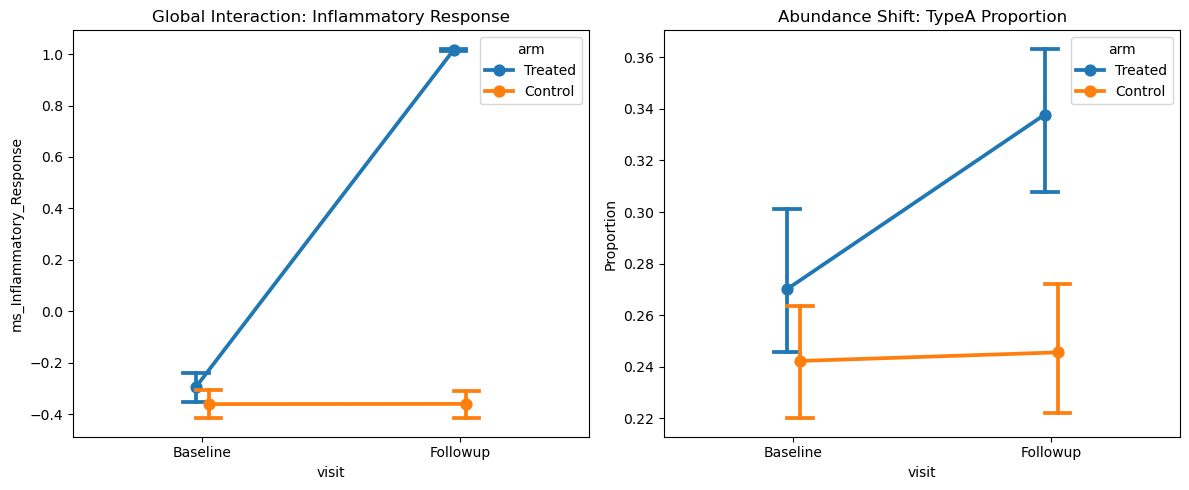

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

st.plot_trial_interaction(adata, "ms_Inflammatory_Response", design, ax=axes[0])
axes[0].set_title("Global Interaction: Inflammatory Response")

st.plot_abundance_interaction(adata, "TypeA", design, ax=axes[1])
axes[1].set_title("Abundance Shift: TypeA Proportion")

plt.tight_layout()
plt.show()


### Forest Plots
Compare effect sizes across multiple features or cell types.


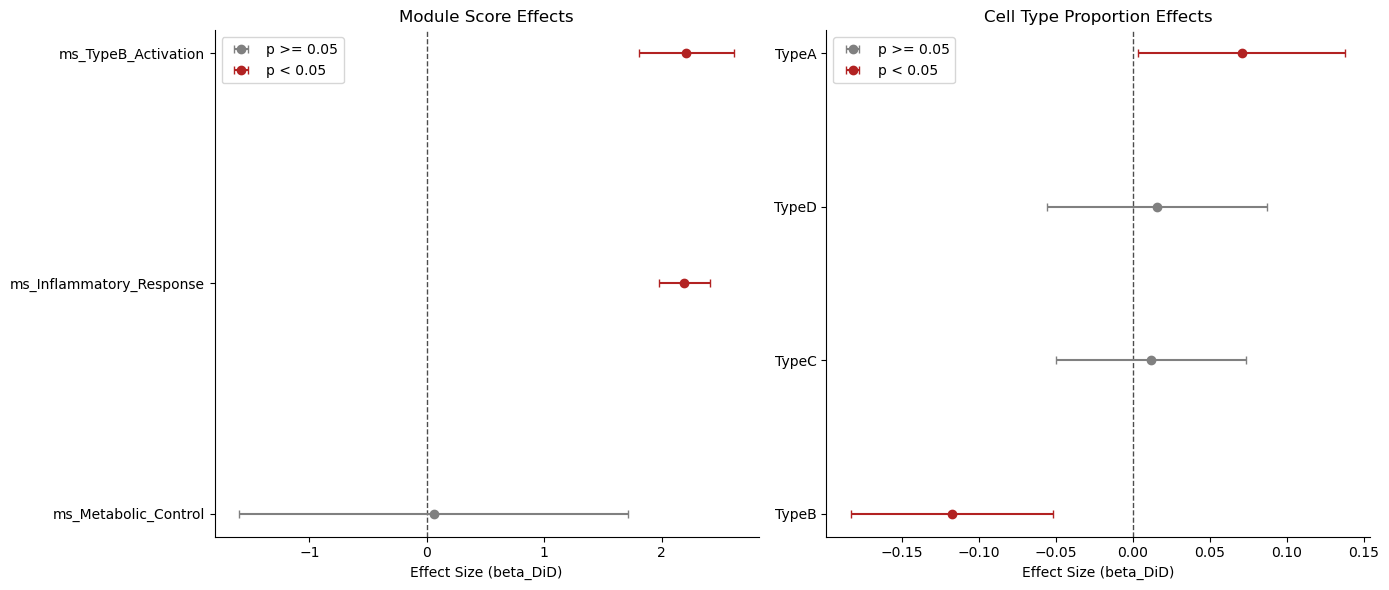

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

st.plot_did_forest(did_res, title="Module Score Effects", ax=axes[0])
st.plot_did_forest(ab_res, title="Cell Type Proportion Effects", feature_col="celltype", ax=axes[1])

plt.tight_layout()
plt.show()


### Within-Arm Longitudinal Analysis (Spaghetti Plots)
Visualize individual participant trajectories.


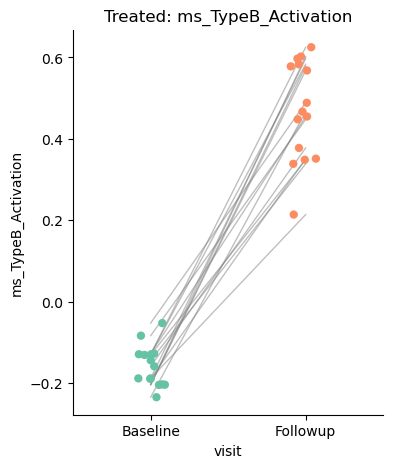

In [13]:
st.plot_within_arm_comparison(
    adata, 
    arm="Treated", 
    feature="ms_TypeB_Activation", 
    design=design, 
    visits=("Baseline", "Followup"),
    plot_type="paired"
)
plt.show()


### Trial-Aware UMAP Panel
Contextualize expression within the global cell-type landscape.


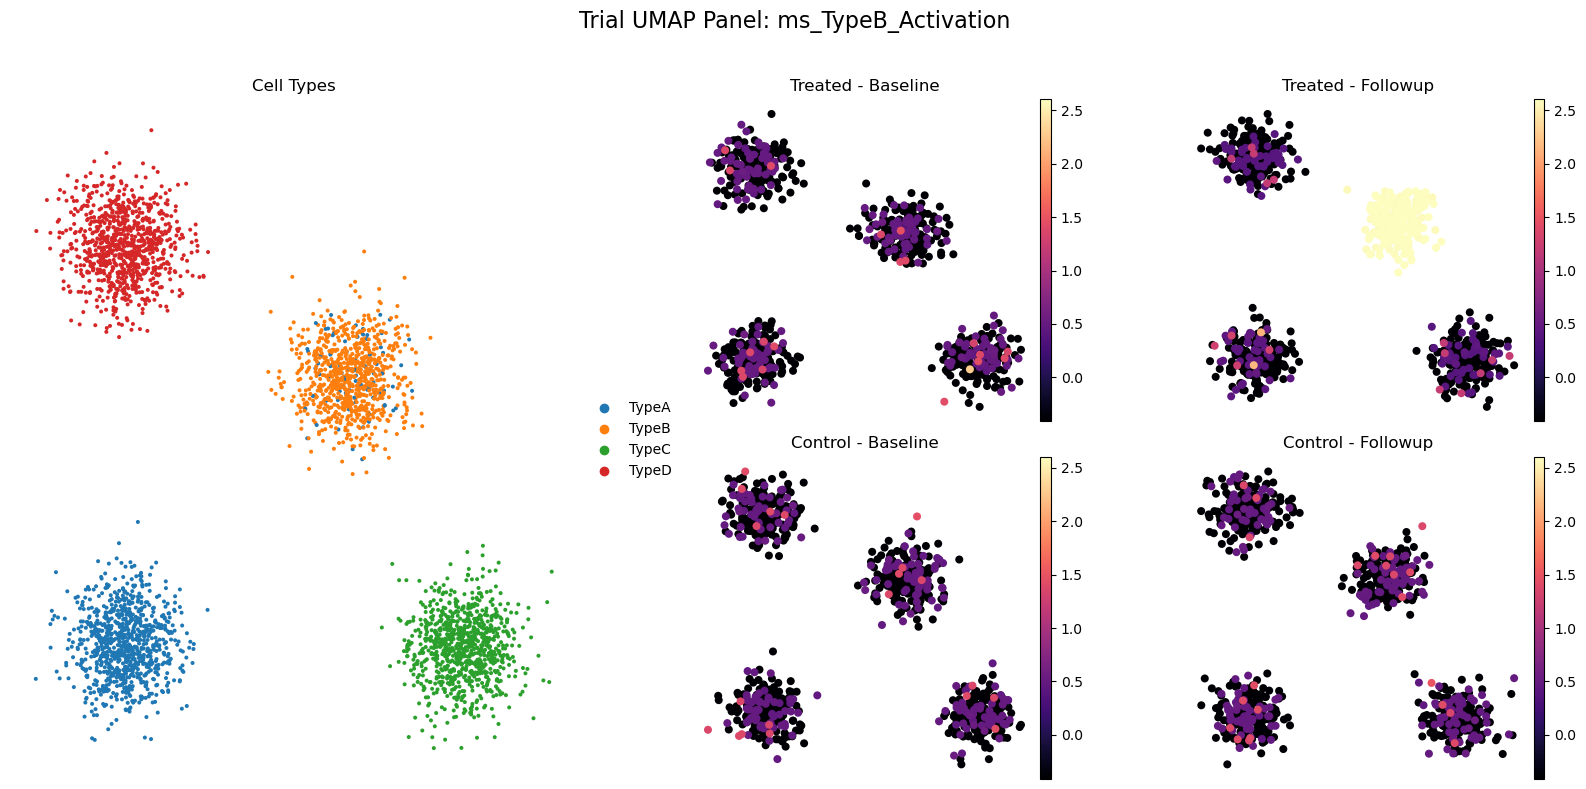

In [14]:
# We already have X_umap from make_blobs, which shows clear clusters.
st.plot_trial_umap_panel(adata, "ms_TypeB_Activation", design)
plt.show()


### GSEA Visualizations: Heatmap


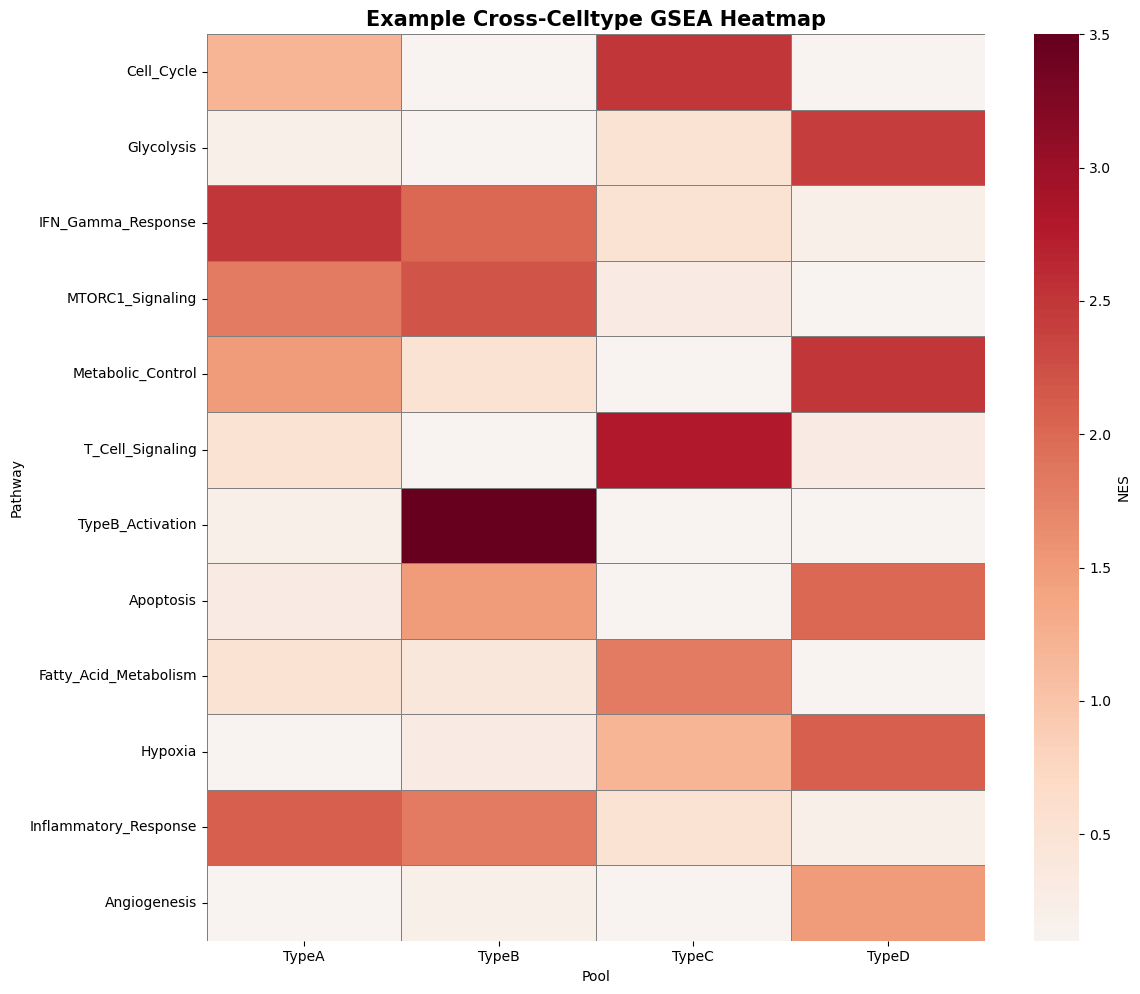

In [15]:
# Mocking multiple cell type GSEA results for demonstration
# We include 12 pathways and 4 cell types for a comprehensive heatmap
mock_gsea_all = pd.DataFrame({
    "Term": ['Inflammatory_Response', 'TypeB_Activation', 'Metabolic_Control', 'T_Cell_Signaling', 'IFN_Gamma_Response', 'Hypoxia', 'Cell_Cycle', 'Apoptosis', 'Angiogenesis', 'Fatty_Acid_Metabolism', 'MTORC1_Signaling', 'Glycolysis'] * 4,
    "pool": ["TypeA"] * 12 + ["TypeB"] * 12 + ["TypeC"] * 12 + ["TypeD"] * 12,
    "NES": [
        2.1, 0.2, 1.5, 0.5, 2.5, 0.1, 1.2, 0.3, 0.1, 0.5, 1.8, 0.2, # TypeA
        1.8, 3.5, 0.5, 0.1, 2.0, 0.3, 0.1, 1.5, 0.2, 0.4, 2.2, 0.1, # TypeB
        0.5, 0.1, 0.1, 2.8, 0.5, 1.2, 2.5, 0.1, 0.1, 1.8, 0.3, 0.5, # TypeC
        0.2, 0.1, 2.5, 0.3, 0.2, 2.1, 0.1, 2.0, 1.5, 0.1, 0.1, 2.4  # TypeD
    ],
    "FDR q-val": [
        0.01, 0.8, 0.05, 0.6, 0.001, 0.9, 0.01, 0.8, 0.9, 0.7, 0.01, 0.8,
        0.02, 0.001, 0.7, 0.9, 0.01, 0.8, 0.9, 0.01, 0.8, 0.7, 0.001, 0.9,
        0.7, 0.9, 0.9, 0.001, 0.7, 0.05, 0.001, 0.8, 0.9, 0.01, 0.7, 0.6,
        0.9, 0.9, 0.001, 0.8, 0.9, 0.01, 0.8, 0.01, 0.05, 0.9, 0.8, 0.001
    ],
    "collection": ["Demo"] * 48
})

st.plot_gsea_heatmap(mock_gsea_all, collection="Demo", fdr_thresh=0.1, figsize=(12, 10))
plt.title("Example Cross-Celltype GSEA Heatmap", fontsize=15, fontweight='bold')
plt.show()

### Trial Dotplot
Condensed view of expression across arms and cell types.


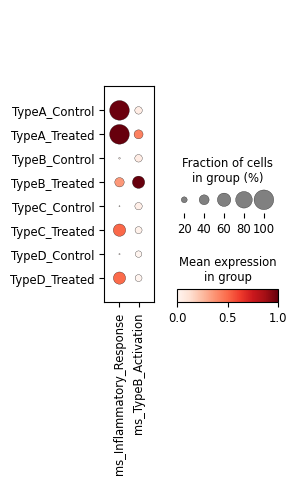

In [16]:
st.plot_trial_dotplot(
    adata, 
    features=["ms_Inflammatory_Response", "ms_TypeB_Activation"], 
    design=design,
    standard_scale="var"
)
plt.show()


## 9. Conclusion

The `sctrial` package provides a unified framework for:
1. **Controlling for heterogeneity** via participant fixed effects.
2. **Identifying specific responders** via Difference-in-Differences.
3. **Validating findings** through robust inference and stratified analysis.
4. **Communicating results** through high-impact, trial-aware visualizations.

Workflow completed successfully!
